In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.681983,0.072232,-0.022147,-0.098422,-0.064869,-0.154963,-0.351051,-0.205326,-0.264072,-0.404946,...,0.219845,-0.421688,-0.407611,0.649193,-0.562251,-0.485901,-0.476493,-0.315438,-0.628430,-0.413296
1,1.006304,-1.302158,-1.424304,-1.209119,-1.167748,-1.275109,-0.883607,-1.196220,-0.663487,-0.804734,...,1.527450,2.223783,0.815169,-1.567292,-0.562251,2.201059,1.084993,1.967842,1.565306,0.413103
2,0.523938,0.584632,0.622463,0.280542,0.451165,0.168246,0.227903,0.449566,0.117578,0.630836,...,-0.494051,-0.206168,-0.017635,0.728066,-0.202838,-0.292141,-0.900502,-0.805067,-0.716683,-0.302865
3,1.049432,-0.986261,-1.284222,-1.147026,-1.233102,-1.350955,-0.556796,-0.966118,-0.649352,-0.719083,...,1.240309,1.677006,0.872919,-1.385502,-0.562251,0.020087,1.125919,-0.805067,0.825461,0.917326
4,0.935477,-0.686277,-0.768038,-0.568449,-0.838469,-0.503670,-0.397572,-0.585393,-0.599652,-0.093676,...,-0.494051,-0.120491,0.768381,-1.787743,1.514080,2.295595,1.423898,2.359078,2.627010,2.164951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.125182,-0.022089,-0.563023,-0.671191,-0.597238,-0.528508,-0.796924,-0.702160,-0.500356,-0.648734,...,-0.494051,-0.278432,-0.429414,0.422155,-0.562251,-0.723888,-0.097562,-0.805067,-0.670464,-0.437236
135,0.421312,1.711257,0.776091,-0.163918,0.111108,0.238540,0.089609,0.057012,0.010885,0.105783,...,-0.266222,-0.129499,0.269550,0.163495,-0.562251,0.340120,-0.400566,-0.180035,-0.330996,0.240232
136,0.504939,0.995873,0.104368,-0.445412,-0.720746,-0.262816,0.239847,-0.442112,-0.290613,-0.149611,...,-0.494051,-0.731873,-0.968902,0.980469,-0.562251,-0.935904,-0.468144,-0.805067,-0.768158,-0.030746
137,-0.485754,-0.279046,-0.015696,0.143137,0.007743,-0.062119,-0.191452,0.010924,-0.197257,-0.092981,...,-0.494051,-0.473789,-0.042353,0.070429,-0.562251,-0.041198,0.025938,-0.374777,-0.303401,0.428295


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

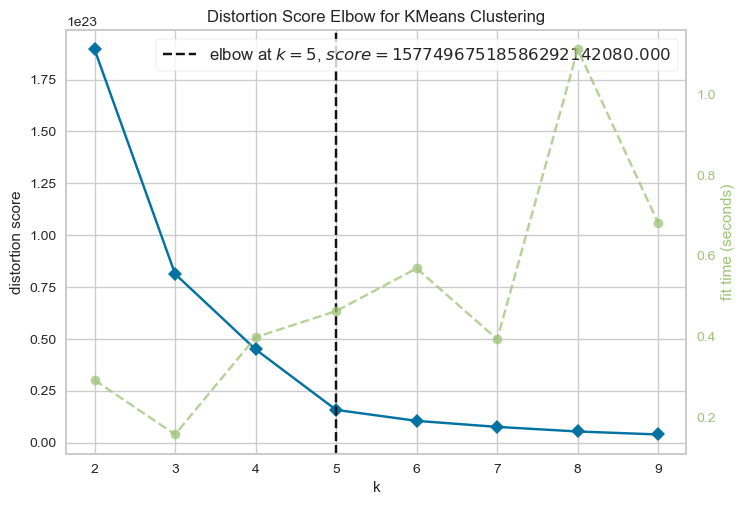

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: shape_Sphericity
Correlation coefficient: 1.007246376811595


1
Most correlated column: gldm_DependenceNonUniformityNormalized_d_1_CT_b20
Correlation coefficient: 1.0072463768115951


2
Most correlated column: glcm_MCC_d_1_CT_b20
Correlation coefficient: 1.0072463768115953


3
Most correlated column: glszm_SizeZoneNonUniformity_PET_b2
Correlation coefficient: 1.0072463768115953


4
Most correlated column: glszm_HighGrayLevelZoneEmphasis_PET_c04
Correlation coefficient: 1.0072463768115953




In [22]:
selected_features

['shape_Sphericity',
 'gldm_DependenceNonUniformityNormalized_d_1_CT_b20',
 'glcm_MCC_d_1_CT_b20',
 'glszm_SizeZoneNonUniformity_PET_b2',
 'glszm_HighGrayLevelZoneEmphasis_PET_c04']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [26]:
X_new

,shape_Sphericity,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glcm_MCC_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,0.761164,0.055238,0.817715,3.470588,20.909091
1,0.697049,0.050688,0.773956,1.250000,17.583333
2,0.565792,0.048612,0.810414,1.600000,13.000000
3,0.684364,0.077182,0.710132,1.000000,18.818182
4,0.503142,0.073116,0.567600,1.461538,17.481481
...,...,...,...,...,...
134,0.742102,0.052052,0.790123,1.000000,15.000000
135,0.722918,0.039528,0.826556,1.250000,16.050000
136,0.652963,0.039913,0.697606,3.580645,16.000000
137,0.724255,0.040037,0.753842,1.428571,14.125000


In [27]:
X_new_std

,shape_Sphericity,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glcm_MCC_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,1.075042,0.771033,0.482340,0.295403,1.588680
1,0.242767,0.349452,-0.140484,-0.559920,0.719022
2,-1.461057,0.157028,0.378424,-0.425107,-0.479481
3,0.078112,2.804650,-1.048871,-0.656214,1.041925
4,-2.274305,2.427799,-3.077512,-0.478440,0.692389
...,...,...,...,...,...
134,0.827589,0.475848,0.089627,-0.656214,0.043502
135,0.578577,-0.684808,0.608165,-0.559920,0.318068
136,-0.329498,-0.649065,-1.227159,0.337795,0.304994
137,0.595927,-0.637641,-0.426754,-0.491138,-0.185303


In [28]:
MAASTRO_new

,shape_Sphericity,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glcm_MCC_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,0.668072,0.039893,0.734071,3.333333,10.218750
1,0.669961,0.044395,0.828113,1.153846,12.055556
2,0.624081,0.040159,0.778776,1.444444,19.312500
3,0.577624,0.061403,0.864230,1.000000,15.611111
4,0.630933,0.039451,0.842091,1.153846,10.107143
...,...,...,...,...,...
94,0.671754,0.040698,0.813111,4.428571,16.684211
95,0.632189,0.051691,0.857525,1.105263,19.363636
96,0.645548,0.039945,0.796506,1.000000,10.333333
97,0.727488,0.047941,0.836464,2.760000,13.941176


In [29]:
MAASTRO_new_std

,shape_Sphericity,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,glcm_MCC_d_1_CT_b20,glszm_SizeZoneNonUniformity_PET_b2,glszm_HighGrayLevelZoneEmphasis_PET_c04
0,-0.133381,-0.651003,-0.708161,0.242536,-1.206755
1,-0.108854,-0.233801,0.630334,-0.596956,-0.726446
2,-0.704414,-0.626272,-0.071881,-0.485024,1.171185
3,-1.307469,1.342407,1.144373,-0.656214,0.203303
4,-0.615466,-0.691949,0.829272,-0.596956,-1.235939
...,...,...,...,...,...
94,-0.085581,-0.576406,0.416811,0.664398,0.483909
95,-0.599161,0.442402,1.048942,-0.615669,1.184557
96,-0.425762,-0.646098,0.180468,-0.656214,-1.176792
97,0.637891,0.094875,0.749184,0.021700,-0.233371


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:01:50,536] A new study created in memory with name: no-name-171e552a-5d6c-4c59-b133-9d1aca81ed7a


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726


[I 2024-04-16 01:01:51,209] A new study created in memory with name: no-name-742cb088-7880-4397-8cda-fc1262f784a8


Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.6525821596244131
[I 2024-04-16 01:01:51,200] Trial 0 finished with value: 0.6890147823582665 and parameters: {}. Best is trial 0 with value: 0.6890147823582665.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6890147823582665], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 50, 752056), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 51, 199822), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6890147823582665


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22831261713063275
Fold 2 IBS: 0.18037062869680037
Fold 3 IBS: 0.18918087056002802
Fold 4 IBS: 0.20418524178081862
Fold 5 IBS: 0.20552683924591655
[I 2024-04-16 01:01:51,760] Trial 0 finished with value: 0.20151523948283928 and parameters: {}. Best is trial 0 with value: 0.20151523948283928.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20151523948283928], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 51, 257626), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 51, 759564), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20151523948283928


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.689
train_ibs:  0.202


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.585
IBS score: 0.226


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:01:52,179] A new study created in memory with name: no-name-4287787d-b0f5-48a3-959d-98ca3df87d49


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6774891774891775
Fold 2 C-index: 0.7321428571428571
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6561181434599156


[I 2024-04-16 01:01:52,623] A new study created in memory with name: no-name-4cf931f8-66cf-4c0f-ab1e-dfe31058f419


Fold 5 C-index: 0.7206572769953051
[I 2024-04-16 01:01:52,605] Trial 0 finished with value: 0.7043403145468627 and parameters: {}. Best is trial 0 with value: 0.7043403145468627.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7043403145468627], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 52, 311242), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 52, 603933), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7043403145468627


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651631110232
Fold 2 IBS: 0.22157791135409044
Fold 3 IBS: 0.2045359430313159
Fold 4 IBS: 0.22473803668511463
Fold 5 IBS: 0.2181243104564653
[I 2024-04-16 01:01:53,095] Trial 0 finished with value: 0.21659054356761773 and parameters: {}. Best is trial 0 with value: 0.21659054356761773.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054356761773], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 52, 681491), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 53, 95158), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054356761773


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.704
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.552


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:01:53,664] A new study created in memory with name: no-name-64d18873-4cc9-44e4-a513-aeba70884864


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:01:54,351] Trial 0 finished with value: 0.689087948628616 and parameters: {}. Best is trial 0 with value: 0.689087948628616.


[I 2024-04-16 01:01:54,392] A new study created in memory with name: no-name-21d7a97d-fb9f-4fb2-8f72-dfd76b25ab05




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.689087948628616], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 53, 742205), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 54, 351728), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.689087948628616


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22723704950411835
Fold 2 IBS: 0.1806506629010556
Fold 3 IBS: 0.18837705164060425
Fold 4 IBS: 0.20531443532867213
Fold 5 IBS: 0.2036047381520449
[I 2024-04-16 01:01:55,090] Trial 0 finished with value: 0.20103678750529905 and parameters: {}. Best is trial 0 with value: 0.20103678750529905.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20103678750529905], datetime_start=datetime.datetime(2024, 4, 16, 1, 1, 54, 477158), datetime_complete=datetime.datetime(2024, 4, 16, 1, 1, 55, 89865), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20103678750529905


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.689
train_ibs:  0.201


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.585


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.226


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:01:55,685] A new study created in memory with name: no-name-077b6e78-4f9a-43a7-8ff0-9d7dc0fc1d32


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:01:56,359] Trial 0 finished with value: 0.689931830485156 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.689931830485156.
Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:01:56,809] Trial 1 finished with value: 0.690797631350957 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.690797631350957.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:01:57,415] Trial 2 finished with value: 0.689931830485156 and parameters: {'l1_ratio': 0.22692876841884668}. Best

Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:02:08,330] Trial 24 finished with value: 0.690797631350957 and parameters: {'l1_ratio': 0.21403194296522143}. Best is trial 1 with value: 0.690797631350957.
Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:02:08,839] Trial 25 finished with value: 0.690797631350957 and parameters: {'l1_ratio': 0.6169743187495462}. Best is trial 1 with value: 0.690797631350957.
Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:02:09,306] Trial 26 finished with value: 0.690797631350957 and parameters: {'l1_ratio': 0.3262690464386221}. Best is trial 1 with value: 0.6907976

Fold 2 C-index: 0.7321428571428571
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 01:02:18,221] Trial 48 finished with value: 0.6960749753150097 and parameters: {'l1_ratio': 0.029390161167306}. Best is trial 45 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 01:02:18,352] Trial 49 finished with value: 0.7136894859079793 and parameters: {'l1_ratio': 0.005040986123852953}. Best is trial 45 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 01:02:18,522] Trial 50 finished with value: 0.7136894859079793 and parameters: {'l1_ratio': 0.017361630318660393}. Best is trial 45 with value: 0.7136894859079793.
Fold 1 

...

Fold 1 IBS: 0.22723856157273892
Fold 2 IBS: 0.18062687015772827
Fold 3 IBS: 0.18837512330535403
Fold 4 IBS: 0.2051385822409847
Fold 5 IBS: 0.2036197415479383
[I 2024-04-16 01:02:40,571] Trial 0 finished with value: 0.20099977576494882 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20099977576494882.
Fold 1 IBS: 0.22726357467537545
Fold 2 IBS: 0.1805419477223248
Fold 3 IBS: 0.18838745948553914
Fold 4 IBS: 0.20490031590937993
Fold 5 IBS: 0.20386271936619238
[I 2024-04-16 01:02:41,117] Trial 1 finished with value: 0.20099120343176233 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.20099120343176233.
Fold 1 IBS: 0.22732495909704603
Fold 2 IBS: 0.18060550153425892
Fold 3 IBS: 0.1884328331428189
Fold 4 IBS: 0.20480110595003387
Fold 5 IBS: 0.20397131548472222
[I 2024-04-16 01:02:41,644] Trial 2 finished with value: 0.201027143041776 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.200991203431762

Fold 2 IBS: 0.18060854079386818
Fold 3 IBS: 0.18842652992083483
Fold 4 IBS: 0.20507608423440507
Fold 5 IBS: 0.20376234555545136
[I 2024-04-16 01:02:54,113] Trial 25 finished with value: 0.2010366880017093 and parameters: {'l1_ratio': 0.49074194377030617}. Best is trial 1 with value: 0.20099120343176233.
Fold 1 IBS: 0.22729151096437664
Fold 2 IBS: 0.18054755873423797
Fold 3 IBS: 0.18840904245260054
Fold 4 IBS: 0.2048948690231926
Fold 5 IBS: 0.20390510045340793
[I 2024-04-16 01:02:54,623] Trial 26 finished with value: 0.2010096163255631 and parameters: {'l1_ratio': 0.3031205588518094}. Best is trial 1 with value: 0.20099120343176233.
Fold 1 IBS: 0.2272219864666988
Fold 2 IBS: 0.1806523722943835
Fold 3 IBS: 0.18836506213231205
Fold 4 IBS: 0.20521558731547762
Fold 5 IBS: 0.20357921654466274
[I 2024-04-16 01:02:55,260] Trial 27 finished with value: 0.20100684495070692 and parameters: {'l1_ratio': 0.9380502933884085}. Best is trial 1 with value: 0.20099120343176233.
Fold 1 IBS: 0.22733772770

Fold 1 IBS: 0.22724522027916375
Fold 2 IBS: 0.18054191805346645
Fold 3 IBS: 0.1883744585324413
Fold 4 IBS: 0.20495423350677813
Fold 5 IBS: 0.2038259700225655
[I 2024-04-16 01:03:11,915] Trial 50 finished with value: 0.20098836007888302 and parameters: {'l1_ratio': 0.3345162751174248}. Best is trial 47 with value: 0.2009849270625737.
Fold 1 IBS: 0.22728152490413053
Fold 2 IBS: 0.180564275456402
Fold 3 IBS: 0.1884026295135119
Fold 4 IBS: 0.20494709716411927
Fold 5 IBS: 0.20388127287223567
[I 2024-04-16 01:03:12,668] Trial 51 finished with value: 0.20101535998207992 and parameters: {'l1_ratio': 0.3625298282124449}. Best is trial 47 with value: 0.2009849270625737.
Fold 1 IBS: 0.22723884442229786
Fold 2 IBS: 0.1805426448901278
Fold 3 IBS: 0.18843901739141744
Fold 4 IBS: 0.204887263784039
Fold 5 IBS: 0.20381626763397764
[I 2024-04-16 01:03:13,361] Trial 52 finished with value: 0.20098480762437196 and parameters: {'l1_ratio': 0.3300255614207927}. Best is trial 52 with value: 0.200984807624371

Fold 5 IBS: 0.2039144983400731
[I 2024-04-16 01:03:30,690] Trial 74 finished with value: 0.20099348038294798 and parameters: {'l1_ratio': 0.21173079916280807}. Best is trial 63 with value: 0.20098450293499223.
Fold 1 IBS: 0.2273257965853868
Fold 2 IBS: 0.18060487925883076
Fold 3 IBS: 0.18843347635686372
Fold 4 IBS: 0.20480094400964213
Fold 5 IBS: 0.20397257843519673
[I 2024-04-16 01:03:31,472] Trial 75 finished with value: 0.20102753492918404 and parameters: {'l1_ratio': 0.22729020203024147}. Best is trial 63 with value: 0.20098450293499223.
Fold 1 IBS: 0.227313189732469
Fold 2 IBS: 0.18056032155611046
Fold 3 IBS: 0.18842725798805773
Fold 4 IBS: 0.20501454837953786
Fold 5 IBS: 0.2037782031219354
[I 2024-04-16 01:03:32,182] Trial 76 finished with value: 0.2010187041556221 and parameters: {'l1_ratio': 0.3909641258878819}. Best is trial 63 with value: 0.20098450293499223.
Fold 1 IBS: 0.22724727281942905
Fold 2 IBS: 0.18055305809618014
Fold 3 IBS: 0.18844367588546881
Fold 4 IBS: 0.20484013

Fold 1 IBS: 0.22729407573396063
Fold 2 IBS: 0.18056427472995004
Fold 3 IBS: 0.18840996418488537
Fold 4 IBS: 0.20484865044966633
Fold 5 IBS: 0.20391712183812535
[I 2024-04-16 01:03:52,022] Trial 99 finished with value: 0.20100681738731754 and parameters: {'l1_ratio': 0.25370957642064734}. Best is trial 79 with value: 0.20097601985788036.


* Best trial for IBS: 
 FrozenTrial(number=79, state=TrialState.COMPLETE, values=[0.20097601985788036], datetime_start=datetime.datetime(2024, 4, 16, 1, 3, 33, 873660), datetime_complete=datetime.datetime(2024, 4, 16, 1, 3, 34, 591150), params={'l1_ratio': 0.2832214633202066}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=79, value=None)


* Best Score for IBS: 
 0.20097601985788036


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.714
train_ibs:  0.201


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.007238804895064288)

test_cindex : 0.553


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.2832214633202066)

test_ibs:  0.225


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:03:52,593] A new study created in memory with name: no-name-3920f4b1-1741-47c2-86da-3450134b94c7


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7077922077922078
Fold 2 C-index: 0.7142857142857143
Fold 3 C-index: 0.7254901960784313
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6995305164319249
[I 2024-04-16 01:04:00,547] Trial 0 finished with value: 0.7061285876771494 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7061285876771494.
Fold 1 C-index: 0.6406926406926406
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.75
Fold 4 C-index: 0.5654008438818565
Fold 5 C-index: 0.704225352112676
[I 2024-04-16 01:04:05,880] Trial 1 finished with value: 0.6713494816231489 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_features':

Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.7699530516431925
[I 2024-04-16 01:06:02,038] Trial 15 finished with value: 0.738034719917238 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 17, 'n_estimators': 491, 'oob_score': True, 'max_samples': 0.25141113328809755, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 14 with value: 0.7489891880105743.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:06:04,646] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.14975474925617, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08683497083568477, 'warm_start': True}. Best is trial 14 with value: 0.7489891880105743.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-

Fold 5 C-index: 0.5
[I 2024-04-16 01:07:34,413] Trial 30 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 236, 'oob_score': True, 'max_samples': 0.37380441936825887, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.20001380215328324, 'warm_start': True}. Best is trial 23 with value: 0.7655745422692977.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.8075117370892019
[I 2024-04-16 01:07:36,363] Trial 31 finished with value: 0.7574256937414101 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 128, 'oob_score': True, 'max_samples': 0.492105541824858, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.045047253801061546, 'warm_start': True}. Best is trial 23 with value: 0.7655745422692977.
Fold 1 C-index: 0.6493506

...

Fold 1 IBS: 0.1841259716991759
Fold 2 IBS: 0.17251677052228914
Fold 3 IBS: 0.1810494282659278
Fold 4 IBS: 0.24348083860375652
Fold 5 IBS: 0.19226072779263473
[I 2024-04-16 01:14:44,289] Trial 32 finished with value: 0.19468674737675684 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 364, 'oob_score': False, 'max_samples': 0.7029720672113731, 'max_features': None, 'min_weight_fraction_leaf': 0.1794480539070914}. Best is trial 21 with value: 0.19134091736479913.
Fold 1 IBS: 0.17854580762814892
Fold 2 IBS: 0.171272221759185
Fold 3 IBS: 0.17988731022594273
Fold 4 IBS: 0.24557189229860188
Fold 5 IBS: 0.19282815130191328
[I 2024-04-16 01:15:08,516] Trial 33 finished with value: 0.19362107664275835 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 15, 'n_estimators': 474, 'oob_score': False, 'max_samples': 0.8224768464134731, 'max_features': None, 'min_weight_fraction_leaf':

Fold 1 IBS: 0.19223303531264593
Fold 2 IBS: 0.17261159085133887
Fold 3 IBS: 0.18341413290757033
Fold 4 IBS: 0.24753801000126766
Fold 5 IBS: 0.19455395723188446
[I 2024-04-16 01:19:49,348] Trial 48 finished with value: 0.19807014526094147 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'max_depth': 20, 'n_estimators': 114, 'oob_score': False, 'max_samples': 0.8008833864858382, 'max_features': None, 'min_weight_fraction_leaf': 0.16501809975975928}. Best is trial 21 with value: 0.19134091736479913.
Fold 1 IBS: 0.1784077516533028
Fold 2 IBS: 0.17476055157338527
Fold 3 IBS: 0.18506548518701998
Fold 4 IBS: 0.2234394155122491
Fold 5 IBS: 0.2019802868036448
[I 2024-04-16 01:20:16,892] Trial 49 finished with value: 0.1927306981459204 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 13, 'min_samples_leaf': 5, 'max_depth': 14, 'n_estimators': 380, 'oob_score': False, 'max_samples': 0.6950282737982125, 'max_features': None, 'min_weight_fraction_lea

Fold 1 IBS: 0.17741360848041138
Fold 2 IBS: 0.17284682725862804
Fold 3 IBS: 0.18204903292340532
Fold 4 IBS: 0.22744726944633237
Fold 5 IBS: 0.19826975551476675
[I 2024-04-16 01:25:47,756] Trial 64 finished with value: 0.19160529872470877 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 238, 'oob_score': False, 'max_samples': 0.6021155804274579, 'max_features': None, 'min_weight_fraction_leaf': 0.23933569663257717}. Best is trial 21 with value: 0.19134091736479913.
Fold 1 IBS: 0.21401597592091426
Fold 2 IBS: 0.22151225425193147
Fold 3 IBS: 0.20488079991814462
Fold 4 IBS: 0.22478861773722014
Fold 5 IBS: 0.21836889900481668
[I 2024-04-16 01:25:53,739] Trial 65 finished with value: 0.21671330936660543 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 188, 'oob_score': False, 'max_samples': 0.4981197061573123, 'max_features': None, 'min_weight_fraction_lea

Fold 1 IBS: 0.17342994785916258
Fold 2 IBS: 0.17060572958950013
Fold 3 IBS: 0.17951064147551532
Fold 4 IBS: 0.2412519997781511
Fold 5 IBS: 0.19386801118460464
[I 2024-04-16 01:27:38,534] Trial 80 finished with value: 0.19173326597738674 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 169, 'oob_score': True, 'max_samples': 0.7398348716826344, 'max_features': None, 'min_weight_fraction_leaf': 0.24135260257720106}. Best is trial 71 with value: 0.19096363211199413.
Fold 1 IBS: 0.17383276899393493
Fold 2 IBS: 0.17046738644563636
Fold 3 IBS: 0.17966531760120358
Fold 4 IBS: 0.23589238568257428
Fold 5 IBS: 0.19478272612688793
[I 2024-04-16 01:27:44,196] Trial 81 finished with value: 0.1909281169700474 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 176, 'oob_score': True, 'max_samples': 0.7284805957115725, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.17800110153771487
Fold 2 IBS: 0.1689991415359363
Fold 3 IBS: 0.18077873047610066
Fold 4 IBS: 0.2466925209975686
Fold 5 IBS: 0.1939574539264578
[I 2024-04-16 01:29:11,468] Trial 96 finished with value: 0.19368578969475564 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 1, 'n_estimators': 32, 'oob_score': True, 'max_samples': 0.5230641990008291, 'max_features': None, 'min_weight_fraction_leaf': 0.15528230275176616}. Best is trial 93 with value: 0.19085646869456271.
Fold 1 IBS: 0.17693822257353997
Fold 2 IBS: 0.16983820549176465
Fold 3 IBS: 0.18042880521675897
Fold 4 IBS: 0.23689878579126483
Fold 5 IBS: 0.19161221945089682
[I 2024-04-16 01:29:15,455] Trial 97 finished with value: 0.19114324770484503 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 100, 'oob_score': True, 'max_samples': 0.5687205104813582, 'max_features': None, 'min_weight_fraction_leaf': 0.

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.848
train_ibs:  0.191


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=12, max_features=None, max_leaf_nodes=13,
                     max_samples=0.6660041231258214, min_samples_leaf=1,
                     min_weight_fraction_leaf=0.016602557206311843,
                     n_estimators=33, random_state=123, warm_start=True)

test_cindex:  0.492


RandomSurvivalForest(max_depth=2, max_features=None, max_leaf_nodes=4,
                     max_samples=0.5743333383671347, min_samples_split=20,
                     min_weight_fraction_leaf=0.19970625340964432,
                     n_estimators=156, oob_score=True, random_state=123)

test_ibs:  0.235


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:29:28,484] A new study created in memory with name: no-name-093fb798-7433-4ef2-8931-58b592a76250


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.670995670995671
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.7511737089201878
[I 2024-04-16 01:29:31,954] Trial 0 finished with value: 0.7471619102348471 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7471619102348471.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:29:39,337] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. Best is t

Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.7276995305164319
[I 2024-04-16 01:30:57,787] Trial 15 finished with value: 0.7279282239160272 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7489660849185458.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.7566964285714286
Fold 3 C-index: 0.7132352941176471
Fold 4 C-index: 0.6645569620253164
Fold 5 C-index: 0.6854460093896714
[I 2024-04-16 01:31:02,230] Trial 16 finished with value: 0.7016492764831505 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction

Fold 1 C-index: 0.7034632034632035
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7230046948356808
[I 2024-04-16 01:32:17,231] Trial 30 finished with value: 0.7254510983634608 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 12, 'max_depth': 14, 'n_estimators': 455, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.3838693489032564, 'min_weight_fraction_leaf': 0.10926796937519383}. Best is trial 12 with value: 0.7489660849185458.
Fold 1 C-index: 0.645021645021645
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.7046413502109705
Fold 5 C-index: 0.755868544600939
[I 2024-04-16 01:32:22,892] Trial 31 finished with value: 0.7401014060059266 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 408, 'oob_score': False, 'warm_start': True, 'max_features': 'log2',

...

Fold 1 IBS: 0.2072095096902193
Fold 2 IBS: 0.20967141902176661
Fold 3 IBS: 0.19322120922345792
Fold 4 IBS: 0.21940630645972947
Fold 5 IBS: 0.20691123631177835
[I 2024-04-16 01:48:07,533] Trial 30 finished with value: 0.20728393614139035 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 45, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.5085185448402467, 'min_weight_fraction_leaf': 0.10143983652978168}. Best is trial 27 with value: 0.2012583747333414.
Fold 1 IBS: 0.20204000821865178
Fold 2 IBS: 0.2076554438510666
Fold 3 IBS: 0.19452369295062133
Fold 4 IBS: 0.21593992126012385
Fold 5 IBS: 0.21060853092037465
[I 2024-04-16 01:48:13,121] Trial 31 finished with value: 0.20615351944016763 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 82, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.39

Fold 1 IBS: 0.1999498045266181
Fold 2 IBS: 0.2012386844373474
Fold 3 IBS: 0.1917241432189504
Fold 4 IBS: 0.21585881249128766
Fold 5 IBS: 0.20672808762748185
[I 2024-04-16 01:48:57,218] Trial 45 finished with value: 0.2030999064603371 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 94, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.42553745380036007, 'min_weight_fraction_leaf': 0.06319254613153871}. Best is trial 35 with value: 0.19379216074299374.
Fold 1 IBS: 0.21065744004396733
Fold 2 IBS: 0.21485199106536326
Fold 3 IBS: 0.2012507473781957
Fold 4 IBS: 0.22384335387285062
Fold 5 IBS: 0.2172201072805781
[I 2024-04-16 01:49:00,241] Trial 46 finished with value: 0.213564727928191 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 8, 'max_depth': 9, 'n_estimators': 63, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.2921899962

Fold 1 IBS: 0.2116422066493214
Fold 2 IBS: 0.21855008960082345
Fold 3 IBS: 0.2026279438291274
Fold 4 IBS: 0.2238454445107987
Fold 5 IBS: 0.21622369911544462
[I 2024-04-16 01:50:41,451] Trial 60 finished with value: 0.21457787674110312 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 12, 'n_estimators': 291, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.5488896789989888, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 35 with value: 0.19379216074299374.
Fold 1 IBS: 0.19520091268362175
Fold 2 IBS: 0.18942748535243734
Fold 3 IBS: 0.18382972333521425
Fold 4 IBS: 0.20992623239799052
Fold 5 IBS: 0.19724013985306654
[I 2024-04-16 01:50:46,441] Trial 61 finished with value: 0.1951248987244661 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 170, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.744

Fold 1 IBS: 0.1960969001591773
Fold 2 IBS: 0.18613432239012295
Fold 3 IBS: 0.18443615224289742
Fold 4 IBS: 0.2132832603823702
Fold 5 IBS: 0.19716864475722873
[I 2024-04-16 01:52:37,091] Trial 75 finished with value: 0.1954238559863593 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 188, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9323325318529927, 'min_weight_fraction_leaf': 0.0003331056440611952}. Best is trial 35 with value: 0.19379216074299374.
Fold 1 IBS: 0.19605577955771217
Fold 2 IBS: 0.18542348750038606
Fold 3 IBS: 0.182691133369407
Fold 4 IBS: 0.2154496207135126
Fold 5 IBS: 0.19581609668511388
[I 2024-04-16 01:52:43,465] Trial 76 finished with value: 0.19508722356522634 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 13, 'n_estimators': 189, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.94

Fold 1 IBS: 0.20401380766368218
Fold 2 IBS: 0.18878577779176905
Fold 3 IBS: 0.18714209257564884
Fold 4 IBS: 0.21268550721563487
Fold 5 IBS: 0.19739996406947988
[I 2024-04-16 01:54:01,866] Trial 90 finished with value: 0.19800542986324296 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 41, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9997935216629936, 'min_weight_fraction_leaf': 0.12200551761519675}. Best is trial 35 with value: 0.19379216074299374.
Fold 1 IBS: 0.19908314203406557
Fold 2 IBS: 0.18516769259257698
Fold 3 IBS: 0.18135425803345262
Fold 4 IBS: 0.21159106303980985
Fold 5 IBS: 0.19662038464635145
[I 2024-04-16 01:54:05,801] Trial 91 finished with value: 0.1947633080692513 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 7, 'max_depth': 15, 'n_estimators': 116, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.86

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.753
train_ibs:  0.194


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=4, max_features=None, max_leaf_nodes=14,
                   max_samples=0.6862560975412572, min_samples_leaf=8,
                   min_weight_fraction_leaf=0.0005225962234796863,
                   n_estimators=169, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.573


ExtraSurvivalTrees(max_depth=6, max_features=None, max_leaf_nodes=8,
                   max_samples=0.42926514599371063, min_samples_leaf=9,
                   min_samples_split=16,
                   min_weight_fraction_leaf=0.06000982226452639, n_estimators=5,
                   oob_score=True, random_state=123, warm_start=True)

IBS: 0.218


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:54:43,225] A new study created in memory with name: no-name-9334da0a-e65d-4de7-8c33-39abd9d0caaa


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:55:30,727] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:55:54,411] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:07:20,412] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 12 with value: 0.7197407721050462.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:08:45,149] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squar

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:22:28,397] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.8840318412875596, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.27382248438555523, 'n_estimators': 385, 'criterion': 'squared_error', 'ccp_alpha': 2.0183033060186855, 'min_weight_fraction_leaf': 0.33643534713187806, 'max_features': 'auto', 'min_impurity_decrease': 5.889654690360788e-06, 'validation_fraction': 0.8062622793646869, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 12 with value: 0.7197407721050462.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:23:39,576] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7565765917190008, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.4300954216773497, 'n_estimators': 440, 'criterion': 'friedma

...

Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 04:34:50,886] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9027683411994925, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.13472529918097312, 'n_estimators': 381, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.36938177041618503, 'max_features': 'auto', 'min_impurity_decrease': 1.1016843774656315e-07, 'validation_fraction': 0.898549324711475, 'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 3}. Best is trial 53 with value: 0.21453948428807265.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-16 04:35:40,561] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.83247895380525

Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 04:45:30,174] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9104313304151431, 'learning_rate': 0.014815622348446418, 'dropout_rate': 0.1415896279444537, 'n_estimators': 149, 'criterion': 'squared_error', 'ccp_alpha': 0.7060910424624821, 'min_weight_fraction_leaf': 0.2796836959018326, 'max_features': 'auto', 'min_impurity_decrease': 5.127880425748818e-06, 'validation_fraction': 0.916501041728546, 'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 18, 'max_depth': 5}. Best is trial 53 with value: 0.21453948428807265.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 04:46:22,518] Trial 67 finished with value: 0.21659054862241586 and parameters: 

Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560958
[I 2024-04-16 04:55:19,570] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8929907845624171, 'learning_rate': 0.012743037240998442, 'dropout_rate': 0.1661055390191164, 'n_estimators': 396, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.27180012569333806, 'max_features': 1, 'min_impurity_decrease': 6.152390348649176e-07, 'validation_fraction': 0.8258741741641896, 'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 13, 'max_depth': 1}. Best is trial 53 with value: 0.21453948428807265.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 04:56:13,656] Trial 78 finished with value: 0.21659054862241586 and parameters: {'sub

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 05:04:24,404] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6145983543893293, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.1804447165879671, 'n_estimators': 474, 'criterion': 'squared_error', 'ccp_alpha': 0.5735028592443879, 'min_weight_fraction_leaf': 0.24852172109024875, 'max_features': 'auto', 'min_impurity_decrease': 2.0519562185047675e-07, 'validation_fraction': 0.898328514849679, 'min_samples_split': 6, 'max_leaf_nodes': 19, 'min_samples_leaf': 19, 'max_depth': 4}. Best is trial 53 with value: 0.21453948428807265.
Fold 1 IBS: 0.21285760830140107
Fold 2 IBS: 0.21998994079855613
Fold 3 IBS: 0.20360806142877305
Fold 4 IBS: 0.22433252669901452
Fold 5 IBS: 0.21722184960923815
[I 2024-04-16 05:05:24,987] Trial 89 finished with value: 0.21560199736739655 and parameters: 

Fold 1 IBS: 0.21352563807113947
Fold 2 IBS: 0.2207928433356559
Fold 3 IBS: 0.20374930938706803
Fold 4 IBS: 0.2244185605758014
Fold 5 IBS: 0.21738121589910464
[I 2024-04-16 05:12:15,433] Trial 99 finished with value: 0.21597351345375387 and parameters: {'subsample': 0.9482641083389376, 'learning_rate': 0.014100590055197093, 'dropout_rate': 0.1545897918844559, 'n_estimators': 385, 'criterion': 'squared_error', 'ccp_alpha': 0.004421533055331512, 'min_weight_fraction_leaf': 0.24870346167707025, 'max_features': 0.1, 'min_impurity_decrease': 1.4840325332716296e-06, 'validation_fraction': 0.6748895535913024, 'min_samples_split': 16, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 4}. Best is trial 53 with value: 0.21453948428807265.


* Best trial for IBS: 
 FrozenTrial(number=53, state=TrialState.COMPLETE, values=[0.21453948428807265], datetime_start=datetime.datetime(2024, 4, 16, 4, 32, 4, 487986), datetime_complete=datetime.datetime(2024, 4, 16, 4, 33, 2, 538501), params={'subsam

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.72
train_ibs:  0.215


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.009012790345815522,
                                 criterion='squared_error',
                                 dropout_rate=0.33861800402640424,
                                 learning_rate=0.0037144148991183562,
                                 max_features='auto', max_leaf_nodes=17,
                                 min_impurity_decrease=3.6437095962407636e-07,
                                 min_samples_leaf=7, min_samples_split=20,
                                 min_weight_fraction_leaf=0.3356273892837128,
                                 n_estimators=449, random_state=123,
                                 subsample=0.6670121615052671,
                                 validation_fraction=0.9239524359558166)

C-index score: 0.545


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009625013743012712,
                                 criterion='squared_error',
                                 dropout_rate=0.1897783294507234,
                                 learning_rate=0.015420772490455037,
                                 max_features='auto', max_leaf_nodes=14,
                                 min_impurity_decrease=5.869825897765074e-07,
                                 min_samples_leaf=13, min_samples_split=20,
                                 min_weight_fraction_leaf=0.29880213170319914,
                                 n_estimators=430, random_state=123,
                                 subsample=0.9101431135071837,
                                 validation_fraction=0.9964423942006735)

IBS: 0.221


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 05:12:31,927] A new study created in memory with name: no-name-a5121134-97f3-4c58-8681-a0d67fa009ed


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:12:32,683] Trial 0 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:12:38,660] Trial 1 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-ind

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:13:19,922] Trial 19 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.765021860726683, 'dropout_rate': 0.3035704063657264, 'n_estimators': 413, 'learning_rate': 0.03357607541426853}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:13:22,006] Trial 20 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.5885634880326687, 'n_estimators': 295, 'learning_rate': 0.0817175642960023}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-in

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:13:48,896] Trial 38 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.7346055919438538, 'dropout_rate': 0.6483160922293313, 'n_estimators': 392, 'learning_rate': 0.09857822999734547}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.7323943661971831
[I 2024-04-16 05:13:51,983] Trial 39 finished with value: 0.7136894859079793 and parameters: {'subsample': 0.4089229065700218, 'dropout_rate': 0.2793220037141419, 'n_estimators': 309, 'learning_rate': 0.07687051653105845}. Best is trial 0 with value: 0.7136894859079793.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.6624472573839663
Fold 5 C-i

...

Fold 4 IBS: 0.210220611828402
Fold 5 IBS: 0.1886953647768417
[I 2024-04-16 05:16:11,318] Trial 19 finished with value: 0.19317729880006454 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.19317729880006454.
Fold 1 IBS: 0.19422541331939105
Fold 2 IBS: 0.1882419773115805
Fold 3 IBS: 0.18409169645780737
Fold 4 IBS: 0.20864053415700584
Fold 5 IBS: 0.18950093223443223
[I 2024-04-16 05:16:11,634] Trial 20 finished with value: 0.1929401106960434 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 20 with value: 0.1929401106960434.
Fold 1 IBS: 0.19375972176161377
Fold 2 IBS: 0.19104880620979153
Fold 3 IBS: 0.18648213846014478
Fold 4 IBS: 0.20810687315432577
Fold 5 IBS: 0.19295238906387663
[I 2024-04-16 05:16:11,881] Trial 21 finished with value: 0.194469985729950

Fold 5 IBS: 0.19734634902363724
[I 2024-04-16 05:16:24,354] Trial 38 finished with value: 0.21967912072743134 and parameters: {'subsample': 0.24276783442088262, 'dropout_rate': 0.13272164755980653, 'n_estimators': 87, 'learning_rate': 0.06952328337469094}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.19425199130724533
Fold 2 IBS: 0.18919788026883572
Fold 3 IBS: 0.1846687129175461
Fold 4 IBS: 0.2095154755197313
Fold 5 IBS: 0.19016104135270756
[I 2024-04-16 05:16:24,600] Trial 39 finished with value: 0.1935590202732132 and parameters: {'subsample': 0.3645779440068705, 'dropout_rate': 0.9451944095204212, 'n_estimators': 32, 'learning_rate': 0.055414173921640594}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.19382347350487195
Fold 2 IBS: 0.19385633200114685
Fold 3 IBS: 0.18739980802076284
Fold 4 IBS: 0.20808365497444958
Fold 5 IBS: 0.1947284819411706
[I 2024-04-16 05:16:24,927] Trial 40 finished with value: 0.19557835008848037 and parameters: {'subsamp

Fold 5 IBS: 0.1872729687829139
[I 2024-04-16 05:16:33,503] Trial 57 finished with value: 0.20111499489534218 and parameters: {'subsample': 0.12697716977831164, 'dropout_rate': 0.5129685790315293, 'n_estimators': 76, 'learning_rate': 0.04513905241843112}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.20207801378631648
Fold 2 IBS: 0.20790360574658115
Fold 3 IBS: 0.195507623348807
Fold 4 IBS: 0.21472504306026802
Fold 5 IBS: 0.20689087038890636
[I 2024-04-16 05:16:33,716] Trial 58 finished with value: 0.2054210312661758 and parameters: {'subsample': 0.5083086261016132, 'dropout_rate': 0.6688865418632627, 'n_estimators': 27, 'learning_rate': 0.0199212460928067}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.3129569972943597
Fold 2 IBS: 0.32094871707661093
Fold 3 IBS: 0.30498301367017616
Fold 4 IBS: 0.30674364441651
Fold 5 IBS: 0.29713178816447144
[I 2024-04-16 05:16:36,591] Trial 59 finished with value: 0.30855283212442564 and parameters: {'subsample': 0.

Fold 2 IBS: 0.18702397405920923
Fold 3 IBS: 0.1834788620432899
Fold 4 IBS: 0.21304259517227866
Fold 5 IBS: 0.18812897154539662
[I 2024-04-16 05:16:46,278] Trial 77 finished with value: 0.19367379662691736 and parameters: {'subsample': 0.22585423157856324, 'dropout_rate': 0.753350464166684, 'n_estimators': 49, 'learning_rate': 0.043951657617590865}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.20119303486344298
Fold 2 IBS: 0.1874062280897398
Fold 3 IBS: 0.18387751164855584
Fold 4 IBS: 0.21791887772218724
Fold 5 IBS: 0.18637442179756963
[I 2024-04-16 05:16:46,609] Trial 78 finished with value: 0.1953540148242991 and parameters: {'subsample': 0.33590286323863655, 'dropout_rate': 0.8173765973264446, 'n_estimators': 69, 'learning_rate': 0.03817292692267657}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.31208099990465127
Fold 2 IBS: 0.32038729151852485
Fold 3 IBS: 0.30416857428476834
Fold 4 IBS: 0.3035530610339094
Fold 5 IBS: 0.29719639653138846
[I 2024-

Fold 3 IBS: 0.19583970133887715
Fold 4 IBS: 0.24839318432493782
Fold 5 IBS: 0.19366651079800706
[I 2024-04-16 05:16:57,476] Trial 96 finished with value: 0.21491375225967602 and parameters: {'subsample': 0.1574194681500252, 'dropout_rate': 0.7642122117967518, 'n_estimators': 111, 'learning_rate': 0.04270625389484591}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.19426870210394784
Fold 2 IBS: 0.19000755865507532
Fold 3 IBS: 0.1841377313189062
Fold 4 IBS: 0.20874422655280517
Fold 5 IBS: 0.18985754080671097
[I 2024-04-16 05:16:57,844] Trial 97 finished with value: 0.1934031518874891 and parameters: {'subsample': 0.11406016951337736, 'dropout_rate': 0.8831368288669302, 'n_estimators': 44, 'learning_rate': 0.03876637080234097}. Best is trial 31 with value: 0.19292890150251582.
Fold 1 IBS: 0.2040797072545658
Fold 2 IBS: 0.2112598944375636
Fold 3 IBS: 0.197432675041526
Fold 4 IBS: 0.2161665993197358
Fold 5 IBS: 0.21000822028913252
[I 2024-04-16 05:16:58,047] Trial 98 finish

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.714
train_ibs:  0.193


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3575254014553415,
                                              learning_rate=0.05558016213920623,
                                              n_estimators=114,
                                              random_state=123,
                                              subsample=0.7268222670380755)

C-index score: 0.553


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.961860592675692,
                                              learning_rate=0.0562781123341657,
                                              n_estimators=33, random_state=123,
                                              subsample=0.10849767566207504)

IBS: 0.223


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.848,1.0
ExtraSurvivalTrees,0.753,2.0
GradientBoosting,0.720,3.0
CoxElastic,0.714,4.5
ComponentwiseGradientBoosting,0.714,4.5
CoxRidge,0.704,6.0
CoxPH,0.689,7.5
CoxLasso,0.689,7.5


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.191,1.0
ComponentwiseGradientBoosting,0.193,2.0
ExtraSurvivalTrees,0.194,3.0
CoxLasso,0.201,4.5
CoxElastic,0.201,4.5
CoxPH,0.202,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.585,1.5
CoxLasso,0.585,1.5
ExtraSurvivalTrees,0.573,3.0
CoxElastic,0.553,4.5
ComponentwiseGradientBoosting,0.553,4.5
CoxRidge,0.552,6.0
GradientBoosting,0.545,7.0
Randomsurvivalforest,0.492,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.218,1.0
CoxRidge,0.221,2.5
GradientBoosting,0.221,2.5
ComponentwiseGradientBoosting,0.223,4.0
CoxElastic,0.225,5.0
CoxPH,0.226,6.5
CoxLasso,0.226,6.5
Randomsurvivalforest,0.235,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/standard/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-16
